In [1]:
%pip install matplotlib
%pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
testing = pd.read_csv("C:\\Users\\admin\\Desktop\\covid-19\\data\\StatewiseTestingDetails.csv")

In [4]:
testing["Date"] = pd.to_datetime(testing["Date"])

print("Testing start:", testing["Date"].min())
print("Testing end:", testing["Date"].max())

Testing start: 2020-04-01 00:00:00
Testing end: 2021-08-10 00:00:00


In [5]:
print("Total samples:")
print(testing["TotalSamples"].sum())

print("\nTotal positive:")
print(testing["Positive"].sum())

Total samples:
87829949447.0

Total positive:
320053246.0


this total is cumulative 

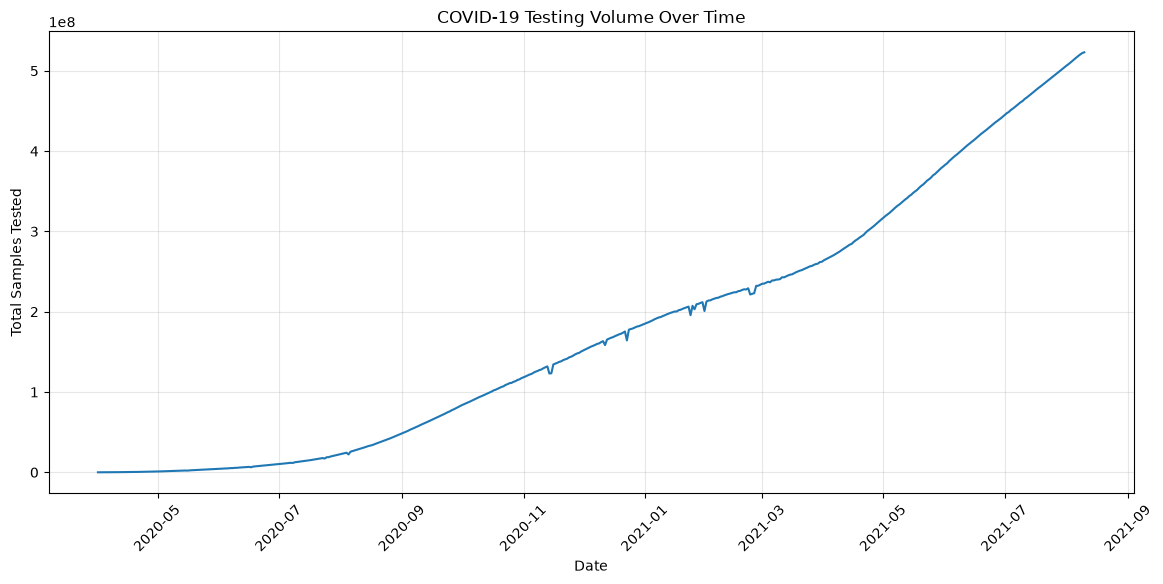

In [8]:
daily_testing = (
    testing.groupby("Date")["TotalSamples"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(14, 6))

plt.plot(daily_testing)

plt.title("COVID-19 Testing Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Total Samples Tested")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

This is one of the most useful variables in the testing dataset.

Instead of simply looking at the number of positive tests, calculate:

Positivity Rate=(Positive Tests/Total Samples)*100


In [9]:
testing["PositivityRate"] = (
    testing["Positive"] / testing["TotalSamples"]
) * 100

In [10]:
display(
    testing[
        ["Date", "State", "TotalSamples", "Positive", "PositivityRate"]
    ].head(10)
)

,Date,State,TotalSamples,Positive,PositivityRate
0,2020-04-17,Andaman and Nicobar Islands,1403.0,12.0,0.855310
1,2020-04-24,Andaman and Nicobar Islands,2679.0,27.0,1.007839
2,2020-04-27,Andaman and Nicobar Islands,2848.0,33.0,1.158708
3,2020-05-01,Andaman and Nicobar Islands,3754.0,33.0,0.879062
4,2020-05-16,Andaman and Nicobar Islands,6677.0,33.0,0.494234
5,2020-05-19,Andaman and Nicobar Islands,6965.0,33.0,0.473798
6,2020-05-20,Andaman and Nicobar Islands,7082.0,33.0,0.465970
7,2020-05-21,Andaman and Nicobar Islands,7167.0,33.0,0.460444
8,2020-05-22,Andaman and Nicobar Islands,7263.0,33.0,0.454358
9,2020-05-23,Andaman and Nicobar Islands,7327.0,33.0,0.450389


National positivity trend

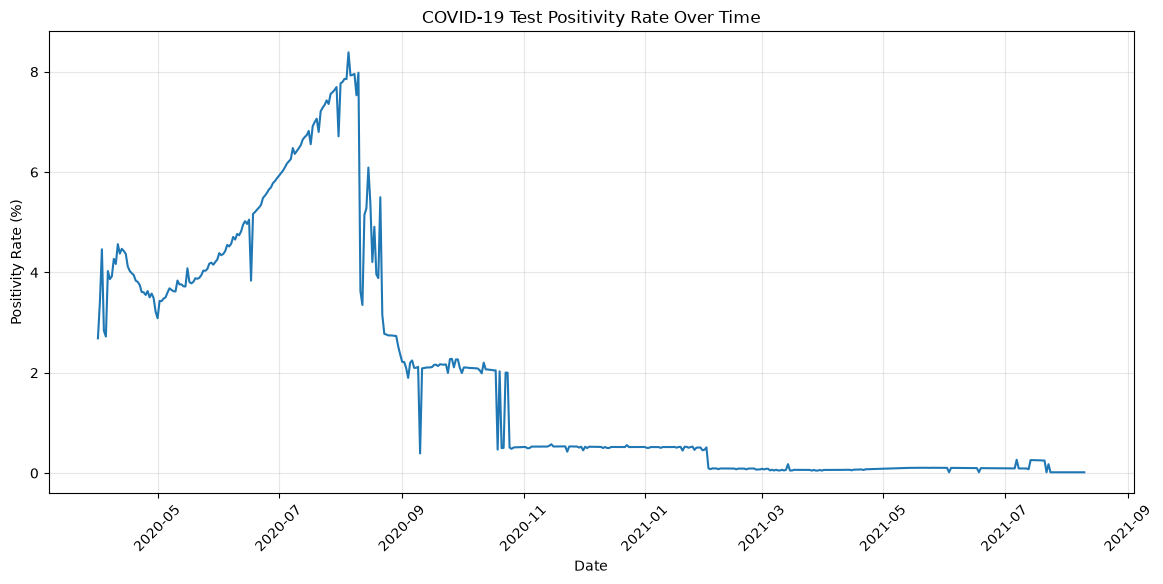

In [11]:
daily_positivity = (
    testing.groupby("Date")
    .agg(
        TotalSamples=("TotalSamples", "sum"),
        Positive=("Positive", "sum")
    )
)

daily_positivity["PositivityRate"] = (
    daily_positivity["Positive"] /
    daily_positivity["TotalSamples"]
) * 100

plt.figure(figsize=(14, 6))

plt.plot(daily_positivity["PositivityRate"])

plt.title("COVID-19 Test Positivity Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Positivity Rate (%)")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

graph has some strange behavior: it drops from around 8% in mid-2020 to almost 0% later

In [12]:
testing_completeness = (
    testing.groupby("Date")
    .agg(
        States_Reporting=("State", "nunique"),
        Total_Rows=("State", "count"),
        Positive_Available=("Positive", "count"),
        TotalSamples_Available=("TotalSamples", "count")
    )
)

display(testing_completeness.head(20))

,States_Reporting,Total_Rows,Positive_Available,TotalSamples_Available
Date,,,,
2020-04-01,3,3,2,3
2020-04-02,8,8,8,8
2020-04-03,5,5,5,5
2020-04-04,2,2,1,2
2020-04-05,6,7,6,7
2020-04-06,5,5,4,5
2020-04-07,11,11,10,11
2020-04-08,12,12,12,12
2020-04-09,18,18,17,18


In [13]:
display(testing_completeness.tail(20))

,States_Reporting,Total_Rows,Positive_Available,TotalSamples_Available
Date,,,,
2021-07-22,35,35,1,35
2021-07-23,35,35,2,35
2021-07-24,35,35,1,35
2021-07-25,35,35,1,35
2021-07-26,35,35,1,35
2021-07-27,35,35,1,35
2021-07-28,35,35,1,35
2021-07-29,35,35,1,35
2021-07-30,35,35,1,35


In [14]:
positive_missing = (
    testing.groupby("Date")["Positive"]
    .apply(lambda x: x.isna().sum())
)

display(positive_missing.head(20))
display(positive_missing.tail(20))

Date
2020-04-01    1
2020-04-02    0
2020-04-03    0
2020-04-04    1
2020-04-05    1
2020-04-06    1
2020-04-07    1
2020-04-08    0
2020-04-09    1
2020-04-10    1
2020-04-11    0
2020-04-12    0
2020-04-13    0
2020-04-14    0
2020-04-15    0
2020-04-16    0
2020-04-17    0
2020-04-18    0
2020-04-19    0
2020-04-20    0
Name: Positive, dtype: int64

Date
2021-07-22    34
2021-07-23    33
2021-07-24    34
2021-07-25    34
2021-07-26    34
2021-07-27    34
2021-07-28    34
2021-07-29    34
2021-07-30    34
2021-07-31    34
2021-08-01    34
2021-08-02    34
2021-08-03    34
2021-08-04    34
2021-08-05    34
2021-08-06    34
2021-08-07    34
2021-08-08    34
2021-08-09    34
2021-08-10    32
Name: Positive, dtype: int64

In [15]:
testing[
    (testing["Date"] >= "2021-03-01") &
    (testing["Date"] <= "2021-06-30")
].head(30)

,Date,State,TotalSamples,Negative,Positive,PositivityRate
291,2021-03-01,Andaman and Nicobar Islands,269799.0,NaN,5020.0,1.860644
292,2021-03-02,Andaman and Nicobar Islands,271193.0,NaN,5020.0,1.851080
293,2021-03-03,Andaman and Nicobar Islands,273010.0,NaN,5022.0,1.839493
294,2021-03-04,Andaman and Nicobar Islands,274849.0,NaN,5024.0,1.827913
295,2021-03-05,Andaman and Nicobar Islands,276471.0,NaN,5024.0,1.817189
296,2021-03-06,Andaman and Nicobar Islands,278437.0,NaN,5024.0,1.804358
297,2021-03-07,Andaman and Nicobar Islands,280041.0,NaN,NaN,NaN
298,2021-03-08,Andaman and Nicobar Islands,281955.0,NaN,5026.0,1.782554
299,2021-03-09,Andaman and Nicobar Islands,283492.0,NaN,5028.0,1.773595
300,2021-03-10,Andaman and Nicobar Islands,285087.0,NaN,5028.0,1.763672


What we can correctly extract from testing

Because TotalSamples is cumulative, we can calculate new tests performed:

NewTests
t
	​

=TotalSamples
t
	​

−TotalSamples
t−1
	​


And similarly, where Positive is available:

NewPositivet=Positivet−Positivet−1
Then:
DailyPositivity=(NewTestst/NewPositivet)×100

But because Positive becomes extremely incomplete later, we should not rely on it as a major forecasting feature.

Instead, the testing dataset can still contribute:

Testing intensity / cumulative testing volume

which is much more reliable because TotalSamples is available for essentially all records.

In [16]:
testing = testing.sort_values(["State", "Date"])

testing["NewTests"] = (
    testing.groupby("State")["TotalSamples"]
    .diff()
)

testing["NewPositive"] = (
    testing.groupby("State")["Positive"]
    .diff()
)

In [17]:
display(
    testing[
        ["Date", "State", "TotalSamples", "NewTests",
         "Positive", "NewPositive"]
    ].head(20)
)

,Date,State,TotalSamples,NewTests,Positive,NewPositive
0,2020-04-17,Andaman and Nicobar Islands,1403.0,NaN,12.0,NaN
1,2020-04-24,Andaman and Nicobar Islands,2679.0,1276.0,27.0,15.0
2,2020-04-27,Andaman and Nicobar Islands,2848.0,169.0,33.0,6.0
3,2020-05-01,Andaman and Nicobar Islands,3754.0,906.0,33.0,0.0
4,2020-05-16,Andaman and Nicobar Islands,6677.0,2923.0,33.0,0.0
5,2020-05-19,Andaman and Nicobar Islands,6965.0,288.0,33.0,0.0
6,2020-05-20,Andaman and Nicobar Islands,7082.0,117.0,33.0,0.0
7,2020-05-21,Andaman and Nicobar Islands,7167.0,85.0,33.0,0.0
8,2020-05-22,Andaman and Nicobar Islands,7263.0,96.0,33.0,0.0
9,2020-05-23,Andaman and Nicobar Islands,7327.0,64.0,33.0,0.0


In [18]:
print("Negative NewTests:", (testing["NewTests"] < 0).sum())
print("Zero NewTests:", (testing["NewTests"] == 0).sum())

Negative NewTests: 23
Zero NewTests: 58


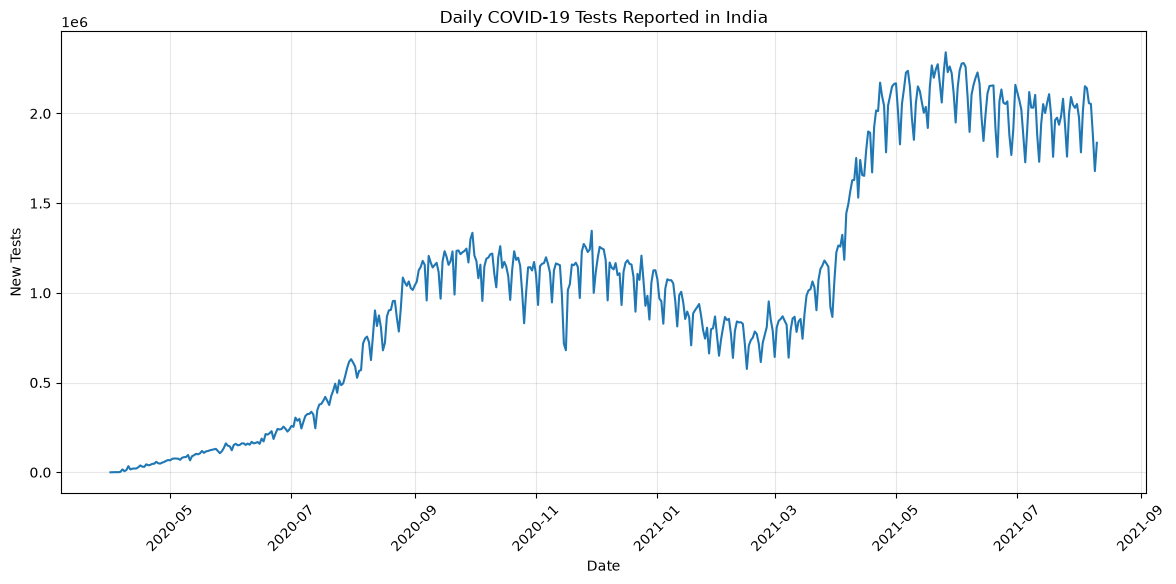

In [19]:
daily_testing = (
    testing.groupby("Date")["NewTests"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(14, 6))

plt.plot(daily_testing)

plt.title("Daily COVID-19 Tests Reported in India")
plt.xlabel("Date")
plt.ylabel("New Tests")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

In [20]:
positive_data = testing.dropna(subset=["NewPositive"]).copy()

print("Total testing records:", len(testing))
print("Records with usable NewPositive:", len(positive_data))

print(
    "Usable percentage:",
    round(len(positive_data) / len(testing) * 100, 2),
    "%"
)

Total testing records: 16336
Records with usable NewPositive: 5535
Usable percentage: 33.88 %


In [21]:
print(
    "Usable NewPositive data ends on:",
    positive_data["Date"].max()
)

Usable NewPositive data ends on: 2021-08-10 00:00:00


Testing coverage expanded substantially over the study period, with cumulative sample counts increasing from April 2020 onward. However, the Positive field becomes highly incomplete in the later period, limiting its reliability for calculating national positivity rates. Therefore, testing volume is more appropriate as an auxiliary feature than reported positive tests for the forecasting model.